# PakWheels Used Car Price Predictor — Analysis

This notebook walks through the exploratory analysis, feature engineering
rationale, model results, and honest limitations of the price prediction
model behind this project.

**Goal:** predict a fair market price for used cars in Pakistan from
listings scraped off PakWheels.com, with a focus on features generic
price predictors (mostly trained on US/European data) don't capture —
import/assembly status and registered-city dynamics.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/processed/cars_features.csv")
print(f"{len(df)} listings, {df['make'].nunique()} makes, {df['model'].nunique()} models")
df.head()

3880 listings, 44 makes, 236 models


,listing_id,url,title,make,model,year,price_pkr,mileage_km,fuel_type,transmission,...,assembly,registered_in,seller_type,car_age,mileage_per_year,price_per_cc,is_imported,listing_province,registered_province,registered_matches_listing
0,11856586.0,https://www.pakwheels.com/used-cars/suzuki-alt...,Suzuki Alto 2020 for sale in Karachi,Suzuki,Alto,2020,2475000.0,85321.0,Petrol,Automatic,...,Local,Karachi,Dealer,6,14220.166667,3750.000000,0.0,Sindh,Sindh,True
1,11683977.0,https://www.pakwheels.com/used-cars/hyundai-so...,Hyundai Sonata 2023 for sale in Karachi,Hyundai,Sonata,2023,9200000.0,14595.0,Petrol,Automatic,...,Local,Karachi,Dealer,3,4865.000000,4600.000000,0.0,Sindh,Sindh,True
2,11849045.0,https://www.pakwheels.com/used-cars/honda-civi...,Honda Civic 2014 for sale in Karachi,Honda,Civic,2014,3450000.0,10.0,Petrol,Automatic,...,Local,Sindh,Dealer,12,0.833333,1916.666667,0.0,Sindh,Sindh,True
3,11763966.0,https://www.pakwheels.com/used-cars/suzuki-alt...,Suzuki Alto 2014 for sale in Karachi,Suzuki,Alto,2014,2300000.0,137313.0,Petrol,Automatic,...,Local,Sindh,Dealer,12,11442.750000,3484.848485,0.0,Sindh,Sindh,True
4,11738521.0,https://www.pakwheels.com/used-cars/hyundai-tu...,Hyundai Tucson 2025 for sale in Karachi,Hyundai,Tucson,2025,11000000.0,7573.0,Hybrid,Automatic,...,Local,Sindh,Dealer,1,7573.000000,6875.000000,0.0,Sindh,Sindh,True


## 1. Dataset overview

Data was scraped directly from PakWheels.com (Pakistan's largest used
car marketplace) — ~3,920 raw listings, reduced to 3,880 after dropping
unparseable/implausible rows during cleaning.

In [2]:
print(df[["price_pkr", "mileage_km", "year", "engine_cc"]].describe())

          price_pkr     mileage_km         year    engine_cc
count  3.880000e+03    3880.000000  3880.000000  3855.000000
mean   4.900612e+06   98361.511082  2015.169588  1427.552789
std    6.158844e+06   82054.148274     7.602262   676.660737
min    1.800000e+05       1.000000  1990.000000     0.000000
25%    2.223750e+06   47000.000000  2010.000000  1000.000000
50%    3.482500e+06   86986.500000  2017.000000  1300.000000
75%    5.650000e+06  131000.000000  2021.000000  1600.000000
max    7.800000e+07  999998.000000  2026.000000  5600.000000


## 2. Market composition

The dataset is heavily skewed toward a handful of makes — Toyota, Suzuki,
and Honda together account for roughly 75% of all listings. This matters
for the model: it will have seen far more examples of these makes, and
we'd expect predictions to be more reliable for them (confirmed later in
the error analysis).

/tmp/ipykernel_503/4166387255.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_makes.values, y=top_makes.index, palette="viridis")


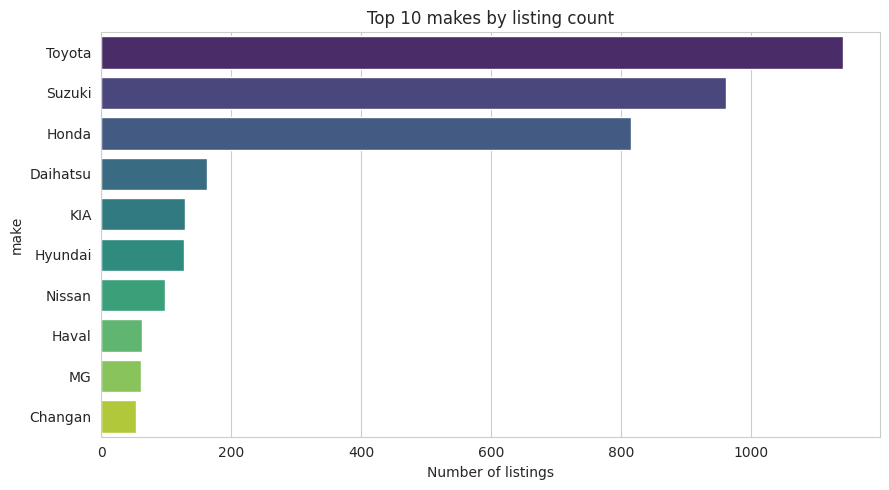

In [3]:
top_makes = df["make"].value_counts().head(10)
plt.figure(figsize=(9, 5))
sns.barplot(x=top_makes.values, y=top_makes.index, palette="viridis")
plt.xlabel("Number of listings")
plt.title("Top 10 makes by listing count")
plt.tight_layout()
plt.savefig("../models/plot_top_makes.png")
plt.show()

## 3. Price distribution

Price is right-skewed, as expected in any used-car market — a long tail
of expensive/luxury vehicles pulls the mean well above the median. This
is why the model was trained on `log1p(price)` rather than raw price:
without the transform, the handful of very expensive cars would dominate
the loss function and the model would underfit the much more common
mid-range cars.

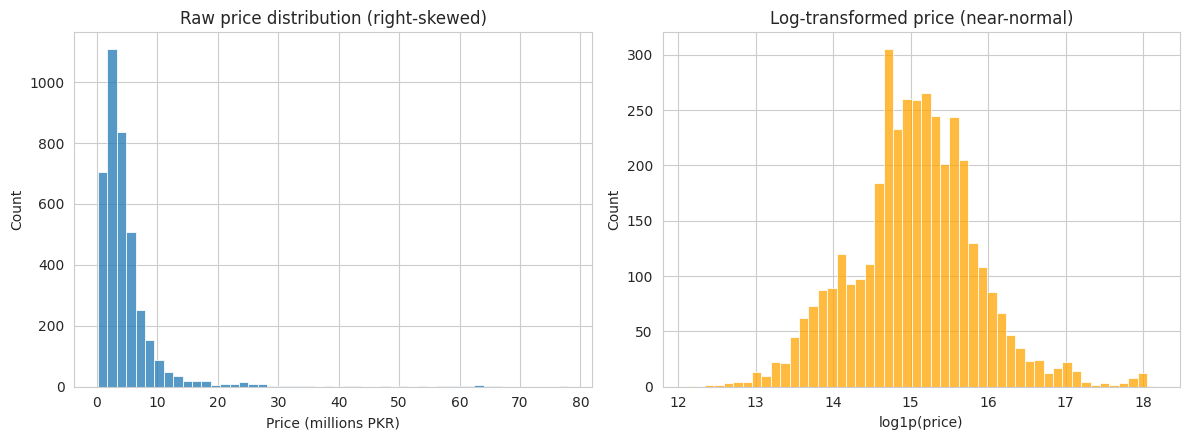

Mean price:   Rs. 4,900,612
Median price: Rs. 3,482,500


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["price_pkr"] / 1e6, bins=50, ax=axes[0])
axes[0].set_xlabel("Price (millions PKR)")
axes[0].set_title("Raw price distribution (right-skewed)")

sns.histplot(np.log1p(df["price_pkr"]), bins=50, ax=axes[1], color="orange")
axes[1].set_xlabel("log1p(price)")
axes[1].set_title("Log-transformed price (near-normal)")
plt.tight_layout()
plt.savefig("../models/plot_price_distribution.png")
plt.show()

print(f"Mean price:   Rs. {df['price_pkr'].mean():,.0f}")
print(f"Median price: Rs. {df['price_pkr'].median():,.0f}")

## 4. Do the Pakistan-specific features actually matter?

This is the core question behind the project's differentiation. Two
features were engineered specifically because generic (US/European)
price-prediction datasets don't have anything like them:

- **Assembly status** — locally assembled vs. imported (JDM/duty status)
- **Registered-in province vs. listing province** — whether a car is
  registered where it's being sold, or brought in from elsewhere

Let's check both against price directly, before even looking at the
model's feature importances.

/tmp/ipykernel_503/3603226456.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="assembly", y=df["price_pkr"] / 1e6, palette="Set2")


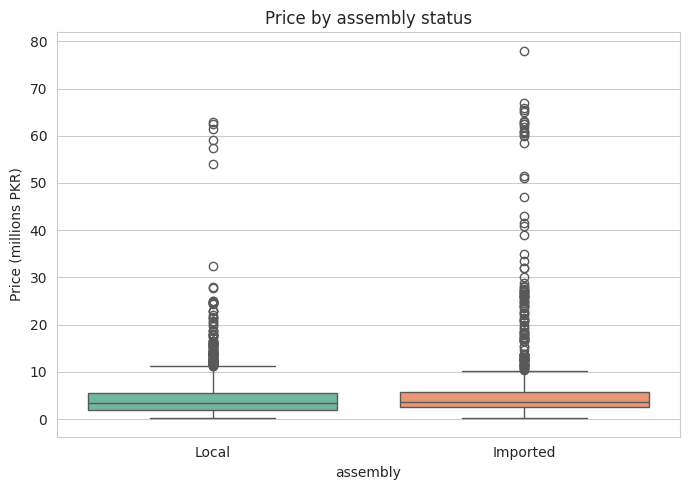

assembly
Imported    3699500.0
Local       3370000.0
Name: price_pkr, dtype: float64


In [5]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="assembly", y=df["price_pkr"] / 1e6, palette="Set2")
plt.ylabel("Price (millions PKR)")
plt.title("Price by assembly status")
plt.tight_layout()
plt.savefig("../models/plot_price_by_assembly.png")
plt.show()

print(df.groupby("assembly")["price_pkr"].median())

Imported cars carry a real, visible price premium over locally
assembled ones in the raw data — confirming this feature was worth
engineering, independent of what the model later says about it.

/tmp/ipykernel_503/2635896614.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


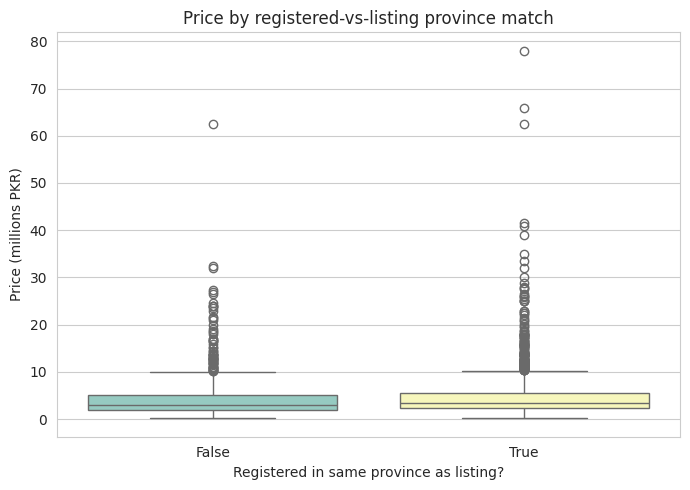

registered_matches_listing
False    3007500.0
True     3455000.0
Name: price_pkr, dtype: float64


In [6]:
matched = df[df["registered_matches_listing"].notna()]
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=matched, x="registered_matches_listing", y=matched["price_pkr"] / 1e6, palette="Set3"
)
plt.xlabel("Registered in same province as listing?")
plt.ylabel("Price (millions PKR)")
plt.title("Price by registered-vs-listing province match")
plt.tight_layout()
plt.savefig("../models/plot_price_by_registration_match.png")
plt.show()

print(matched.groupby("registered_matches_listing")["price_pkr"].median())

The registered-vs-listing gap shows a much smaller difference in the
raw data than assembly status does — a hint that this feature would end
up mattering less to the model, which the feature importance results
below confirm directly.

## 5. Model results

Two models were trained: a Linear Regression baseline (sanity check) and
XGBoost (the real model, using native categorical feature support).
`price_per_cc` was deliberately excluded from training since it's
derived directly from the target (`price / engine_cc`) — including it
would be target leakage.

A hyperparameter search (RandomizedSearchCV, 40 configs x 5-fold CV) was
run afterward to see whether the initial settings were leaving
performance on the table.

In [7]:
with open("../models/model_metadata.json") as f:
    metadata = json.load(f)

m = metadata["test_metrics"]
print(f"Final model test performance:")
print(f"  MAE:  Rs. {m['mae']:,.0f}")
print(f"  RMSE: Rs. {m['rmse']:,.0f}")
print(f"  MAPE: {m['mape']:.1f}%")

if "tuning" in metadata:
    t = metadata["tuning"]
    orig = t["original_metrics"]
    print(f"\nOriginal (untuned) MAE: Rs. {orig['mae']:,.0f} ({orig['mape']:.1f}% MAPE)")
    print(f"Tuning improved the model: {t['improved_on_original']}")

Final model test performance:
  MAE:  Rs. 572,356
  RMSE: Rs. 3,119,148
  MAPE: 9.9%

Original (untuned) MAE: Rs. 579,904 (10.3% MAPE)
Tuning improved the model: True


**Honest take:** hyperparameter tuning gave a modest improvement
(roughly 0.4 percentage points of MAPE), not a dramatic one. That's a
legitimate finding, not a shortcoming of the search — it suggests the
original default-ish settings were already in a reasonable region, and
the ceiling here is more about feature/data quality than tuning depth.

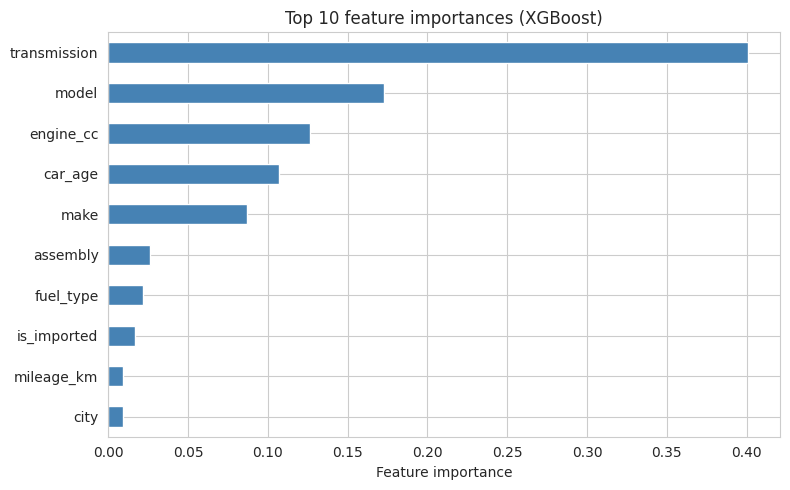

In [8]:
importances = pd.Series(metadata["top_feature_importances"]).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="steelblue")
plt.xlabel("Feature importance")
plt.title("Top 10 feature importances (XGBoost)")
plt.tight_layout()
plt.savefig("../models/plot_feature_importance.png")
plt.show()

`transmission`, `model`, and `engine_cc` dominate — intuitive, since
automatic-vs-manual and the specific car model are naturally strong price
drivers. Notably, **`is_imported`/`assembly` rank in the top 10**,
confirming the Pakistan-specific differentiator is contributing real
signal, not just decoration. `registered_matches_listing` does *not*
make the top 10 — consistent with what the raw-data boxplot above
already suggested.

## 6. Where the model is weak — error analysis

A model's headline MAPE number hides a lot. Breaking errors down by make
and by price bucket tells a much more honest story about where this
model can and can't be trusted.

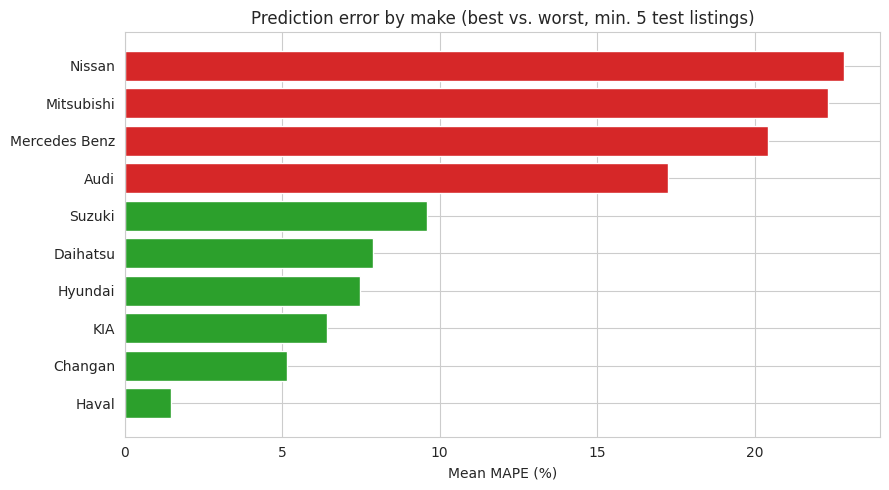

In [9]:
with open("../models/error_analysis.json") as f:
    error_report = json.load(f)

worst = pd.DataFrame(error_report["worst_makes"])
best = pd.DataFrame(error_report["best_makes"])

fig, ax = plt.subplots(figsize=(9, 5))
combined = pd.concat([worst.head(5), best.tail(5)]).drop_duplicates(subset="make")
combined = combined.sort_values("mean_mape")
colors = ["#d62728" if v > 15 else "#2ca02c" for v in combined["mean_mape"]]
ax.barh(combined["make"], combined["mean_mape"], color=colors)
ax.set_xlabel("Mean MAPE (%)")
ax.set_title("Prediction error by make (best vs. worst, min. 5 test listings)")
plt.tight_layout()
plt.savefig("../models/plot_error_by_make.png")
plt.show()

**Rare/luxury makes (Nissan, Mitsubishi, Mercedes-Benz, Audi) predict
worst** — 17-23% MAPE, roughly double the error rate of common makes.
This isn't surprising: the model saw far fewer examples of these during
training, and luxury car pricing depends heavily on trim/spec details
this feature set doesn't capture granularly.

**Common, high-volume makes (Toyota, Honda, Suzuki) predict well** —
7.5-9.6% MAPE, each backed by 180+ test-set listings.

In [10]:
bucket_df = pd.DataFrame(error_report["by_price_quartile"])
print(bucket_df.to_string(index=False))

 price_bucket count          mean_mape     mean_abs_error
     Low (Q1)   182  13.36604457820311  172931.5989010989
 Mid-low (Q2)   180 7.7756443557294785 210365.07638888888
Mid-high (Q3)   181  8.056453874073807  331661.3494475138
    High (Q4)   181   10.3269413209961 1574674.6505524863


**Cheap cars have the worst percentage error despite the smallest
absolute error.** The lowest price quartile shows ~13% MAPE with only
~Rs. 173k average absolute error — a small rupee miss just matters more,
proportionally, on an inexpensive car. This is a real, explainable
limitation of the model rather than a bug, and worth stating plainly
rather than only reporting the headline MAPE.

## 7. Summary

- Final model: XGBoost, MAE ≈ Rs. 572,000, MAPE ≈ 9.9% on held-out data
- The Pakistan-specific `assembly`/`is_imported` feature earns its place
  in the top 10 most important features — the differentiation this
  project was built around is real, not just a framing choice
- `registered_matches_listing` did not turn out to be a strong signal,
  despite the original hypothesis — an honest negative result
- The model is most reliable for common, high-volume makes (Toyota,
  Honda, Suzuki) and least reliable for rare/luxury makes and the
  cheapest price segment — worth stating clearly to anyone using the
  live prediction tool